In [175]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import time
import sys
import importlib
from pathlib import Path

for project_root in (Path.cwd(), Path.cwd().parent):
    if (project_root / 'binary_sync').is_dir():
        sys.path.insert(0, str(project_root))
        break

# Clear previously imported project modules so notebook cells use current source.
for module_name in list(sys.modules):
    if module_name == 'binary_sync' or module_name.startswith('binary_sync.'):
        del sys.modules[module_name]
importlib.invalidate_caches()

from matplotlib.lines import Line2D
from binary_sync.model import sample_instance, Graph
from binary_sync.bp import bp_corr2
from binary_sync.spectral import spectral_corr2
from binary_sync.low_degree import low_degree_corr2 as low_degree_corr
from binary_sync.low_degree import low_degree_weights as compute_low_degree_weights, print_low_degree_weights
from binary_sync.percolation import estimate_percolation_bound
from binary_sync.reporting import format_estimate
from binary_sync.exact_corr_sp import sp_corr2

## Graph Visualization

In [176]:
def draw_graph(
    graph,
    source,
    target,
    ax=None,
    seed=0,
    title=None,
    positions=None,
):
    if source not in graph.nodes:
        raise ValueError("The source is not in the graph.")

    if target not in graph.nodes:
        raise ValueError("The target is not in the graph.")

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    nx_graph = nx.MultiGraph()
    nx_graph.add_nodes_from(graph.nodes)

    for edge_id, edge in enumerate(graph.edges):
        nx_graph.add_edge(edge.u, edge.v, key=edge_id)

    if positions is None:
        positions = nx.spring_layout(nx_graph, seed=seed)

    ordinary_nodes = [
        node
        for node in graph.nodes
        if node not in {source, target}
    ]

    nx.draw_networkx_edges(
        nx_graph,
        positions,
        ax=ax,
        width=1.8,
        edge_color="gray",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=ordinary_nodes,
        ax=ax,
        node_size=700,
        node_color="lightblue",
        edgecolors="black",
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[source],
        ax=ax,
        node_size=850,
        node_color="mediumseagreen",
        edgecolors="black",
        linewidths=2,
    )

    nx.draw_networkx_nodes(
        nx_graph,
        positions,
        nodelist=[target],
        ax=ax,
        node_size=850,
        node_color="darkorange",
        edgecolors="black",
        linewidths=2,
    )



    node_labels = {
        node: ("s" if node == source else "t" if node == target else str(node))
        for node in graph.nodes
    }

    nx.draw_networkx_labels(
        nx_graph,
        positions,
        labels=node_labels,
        ax=ax,
        font_size=10,
    )

    # legend_handles = [
    #     Line2D(
    #         [0],
    #         [0],
    #         marker="o",
    #         color="none",
    #         markerfacecolor="mediumseagreen",
    #         markeredgecolor="black",
    #         markersize=11,
    #         label=f"Source: {source}",
    #     ),
    #     Line2D(
    #         [0],
    #         [0],
    #         marker="o",
    #         color="none",
    #         markerfacecolor="darkorange",
    #         markeredgecolor="black",
    #         markersize=11,
    #         label=f"Sink: {target}",
    #     ),
    # ]

    # ax.legend(
    #     handles=legend_handles,
    #     loc="best",
    #     frameon=False,
    # )

    if title is not None:
        ax.set_title(title)

    ax.set_axis_off()
    return ax

## Trees and Paths

In [177]:
def make_path(p_values):
    graph = Graph()

    for i, p in enumerate(p_values):
        graph.add_edge(i, i + 1, p)

    return graph, 0, len(p_values)

In [178]:
p_values = [0.2, 0.2, 0.2, 0.2]

path, s, t = make_path(p_values)

<Axes: >

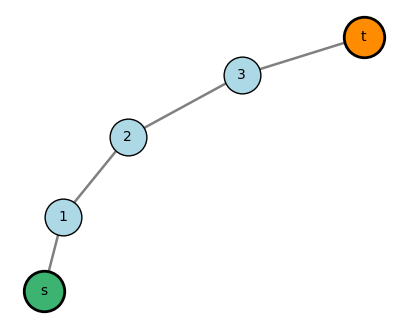

In [179]:
draw_graph(path, s, t)

In [180]:
start = time.perf_counter()
# result_bp = bp_corr2(path, s, t, n_samples=5000, seed=0)['corr2']
result_bp_random = bp_corr2(path, s, t, n_samples=5000, seed=0, init="random")
runtime_bp = time.perf_counter() - start

start = time.perf_counter()
result_spectral = spectral_corr2(path, s, t, alg="naive", n_samples=5000, seed=0)
runtime_spectral = time.perf_counter() - start

start = time.perf_counter()
result_power = spectral_corr2(path, s, t, alg="power", n_samples=10000, seed=0, num_iter=20)
runtime_power = time.perf_counter() - start

start = time.perf_counter()
result_low_degree = low_degree_corr(path, 4, s, t)
runtime_low_degree = time.perf_counter() - start

percolation_bound = estimate_percolation_bound(path, s, t)

In [181]:
spectral_nb = spectral_corr2(path, s, t, alg="nb", n_samples=5000, seed=0)

In [182]:
exact_corr = sp_corr2(path, s, t, 0.2)

In [183]:
print(f"BP: {format_estimate(result_bp_random['corr2'], result_bp_random['standard_error'])} (runtime: {runtime_bp:.4f} s)")
print(f"Naive Spectral: {format_estimate(result_spectral['corr2'], result_spectral['standard_error'])} (runtime: {runtime_spectral:.4f} s)")
print(f"Power Method: {format_estimate(result_power['corr2'], result_power['standard_error'])} (runtime: {runtime_power:.4f} s)")
print(f"Low-degree: {format_estimate(result_low_degree)} (runtime: {runtime_low_degree:.4f} s)")
print(f"Non-backtracking Spectral: {format_estimate(spectral_nb['corr2'], spectral_nb['standard_error'])}")
print(f"Exact correlation: {format_estimate(exact_corr)}")
print(f"Percolation Upper bound: {format_estimate(percolation_bound['bound'], percolation_bound['standard_error'])}")

BP: estimate=0.018387, standard error=0.003800, 95% CI=[0.010939, 0.025836] (runtime: 1.1217 s)
Naive Spectral: estimate=0.018387, standard error=0.003800, 95% CI=[0.010939, 0.025836] (runtime: 0.1357 s)
Power Method: estimate=0.018063, standard error=0.002664, 95% CI=[0.012842, 0.023284] (runtime: 0.8698 s)
Low-degree: estimate=0.016796, standard error=0.000000, 95% CI=[0.016796, 0.016796] (runtime: 0.0001 s)
Non-backtracking Spectral: estimate=0.018387, standard error=0.003800, 95% CI=[0.010939, 0.025836]
Exact correlation: estimate=0.016796, standard error=0.000000, 95% CI=[0.016796, 0.016796]
Percolation Upper bound: estimate=0.016800, standard error=0.000575, 95% CI=[0.015673, 0.017927]


In [184]:
weights = compute_low_degree_weights(path, s, t, 0.2, 4)
print_low_degree_weights(path, weights)

Edge IDs:
  0: (0, 1)
  1: (1, 2)
  2: (2, 3)
  3: (3, 4)

Low-degree weights:
  basis=(0, 1, 2, 3), edges=[(0, 1), (1, 2), (2, 3), (3, 4)], weight=0.129600


## S-P graphs

In [185]:
def make_parallel_branch_graph(m=3, n=3, p=0.1):
    graph = Graph()
    observations = []
    positions = {
        "s": (0, 0),
        "t": (8, 0),
        "a": (4, -3.5),
    }

    # The displayed observation on (s, a) is -1.
    graph.add_edge("s", "a", p)
    observations.append(-1)

    # Paths s -- c_i -- d_i -- t.
    top_heights = np.linspace(2.5, 0.5, m)

    for i, height in enumerate(top_heights, start=1):
        c = f"c_{i}"
        d = f"d_{i}"

        positions[c] = (3, height)
        positions[d] = (5, height)

        graph.add_edge("s", c, p)
        observations.append(1)

        graph.add_edge(c, d, p)
        observations.append(1)

        graph.add_edge(d, "t", p)
        observations.append(1)

    # Paths a -- b_j -- t.
    a_position = np.array(positions["a"], dtype=float)
    t_position = np.array(positions["t"], dtype=float)

    offsets = np.linspace(0.8, -0.8, n)

    for j, offset in enumerate(offsets, start=1):
        b = f"b_{j}"
        fraction = j / (n + 1)

        base_position = (
            (1 - fraction) * a_position
            + fraction * t_position
        )

        positions[b] = tuple(
            base_position + np.array([0, offset])
        )

        graph.add_edge("a", b, p)
        observations.append(1)

        graph.add_edge(b, "t", p)
        observations.append(1)

    return (
        graph,
        "s",
        "t",
        np.array(observations, dtype=int),
        positions,
    )

In [193]:
sp_graph, s, t, observations, positions = make_parallel_branch_graph(m=5, n=5, p=0.2)

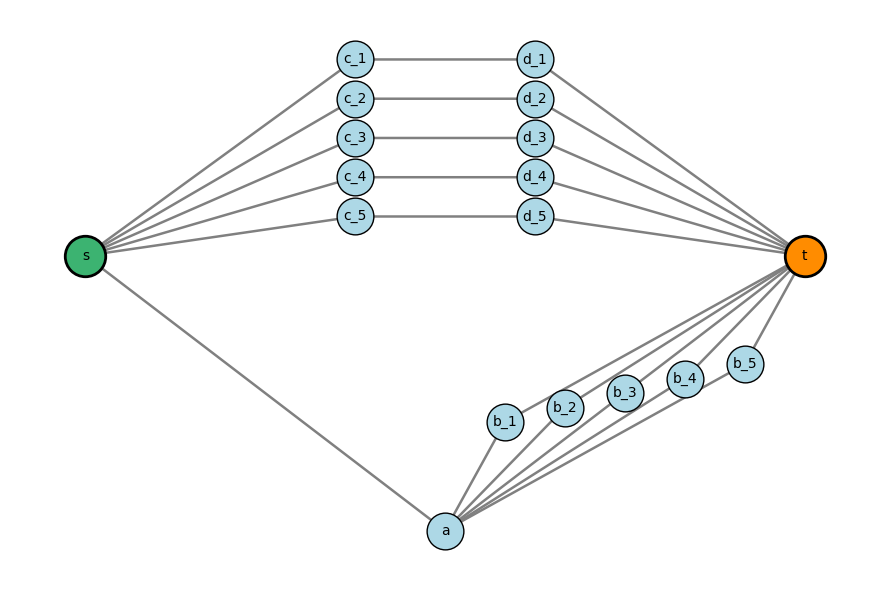

In [194]:

fig, ax = plt.subplots(figsize=(9, 6))

draw_graph(
    sp_graph,
    source=s,
    target=t,
    positions=positions,
    ax=ax,
    # title=r"Parallel-branch graph: $m=n=3$",
)

plt.tight_layout()
plt.show()

In [195]:
bp_initial_zero = np.zeros(2 * len(sp_graph.edges))
bp_initial_one = np.ones(2 * len(sp_graph.edges))

In [196]:
start = time.perf_counter()
result_bp_zero = bp_corr2(
    sp_graph, s, t, n_samples=800, seed=3, initial_point=bp_initial_zero
)
runtime_bp_zero = time.perf_counter() - start

start = time.perf_counter()
result_bp_one = bp_corr2(
    sp_graph, s, t, n_samples=800, seed=3, initial_point=bp_initial_one
)
runtime_bp_one = time.perf_counter() - start

start = time.perf_counter()
result_spectral = spectral_corr2(sp_graph, s, t, alg="naive", n_samples=10000, seed=3)
runtime_spectral = time.perf_counter() - start

start = time.perf_counter()
result_power = spectral_corr2(sp_graph, s, t, alg="power", n_samples=10000, seed=3)
runtime_power = time.perf_counter() - start


# To exactg computation of correlation

percolation_bound = estimate_percolation_bound(sp_graph, s, t)

In [200]:

result_spectral_nb = spectral_corr2(sp_graph, s, t, alg="nb", n_samples=10000, seed=3)

In [201]:
exact_corr_sp = sp_corr2(sp_graph, s, t, 0.2)

In [248]:
start = time.perf_counter()
result_low_degree = low_degree_corr(sp_graph, 10, s, t)
runtime_low_degree = time.perf_counter() - start

In [250]:
print(f"BP (zero initial point): {format_estimate(result_bp_zero['corr2'], result_bp_zero['standard_error'])}", f"(runtime: {runtime_bp_zero:.4f} s)")
print(f"BP (one initial point): {format_estimate(result_bp_one['corr2'], result_bp_one['standard_error'])}", f"(runtime: {runtime_bp_one:.4f} s)")
print(f"Spectral: {format_estimate(result_spectral['corr2'], result_spectral['standard_error'])}", f"(runtime: {runtime_spectral:.4f} s)")
print(f"Power Method: {format_estimate(result_power['corr2'], result_power['standard_error'])}", f"(runtime: {runtime_power:.4f} s)")
print(f"Non-backtracking Spectral: {format_estimate(result_spectral_nb['corr2'], result_spectral_nb['standard_error'])}")
print(f"Low-degree: {format_estimate(result_low_degree)}", f"(runtime: {runtime_low_degree:.4f} s)")
print(f"Exact correlation: {format_estimate(exact_corr_sp)}")
print(f"Percolation Upper bound: {format_estimate(percolation_bound['bound'], percolation_bound['standard_error'])}")

BP (zero initial point): estimate=0.256294, standard error=0.027577, 95% CI=[0.202243, 0.310346] (runtime: 22.5316 s)
BP (one initial point): estimate=0.257872, standard error=0.027681, 95% CI=[0.203618, 0.312126] (runtime: 142.4400 s)
Spectral: estimate=0.214554, standard error=0.008211, 95% CI=[0.198461, 0.230647] (runtime: 0.7707 s)
Power Method: estimate=0.207207, standard error=0.008107, 95% CI=[0.191318, 0.223096] (runtime: 3.1575 s)
Non-backtracking Spectral: estimate=0.000049, standard error=0.000140, 95% CI=[0.000000, 0.000323]
Low-degree: estimate=0.310064, standard error=0.000000, 95% CI=[0.310064, 0.310064] (runtime: 21.4548 s)
Exact correlation: estimate=0.311079, standard error=0.000000, 95% CI=[0.311079, 0.311079]
Percolation Upper bound: estimate=0.354000, standard error=0.002139, 95% CI=[0.349808, 0.358192]


In [251]:
low_degree_weight = compute_low_degree_weights(sp_graph, s, t, p=0.2, degree=10)
print_low_degree_weights(sp_graph, low_degree_weight)

Edge IDs:
  0: (s, a)
  1: (s, c_1)
  2: (c_1, d_1)
  3: (d_1, t)
  4: (s, c_2)
  5: (c_2, d_2)
  6: (d_2, t)
  7: (s, c_3)
  8: (c_3, d_3)
  9: (d_3, t)
  10: (s, c_4)
  11: (c_4, d_4)
  12: (d_4, t)
  13: (s, c_5)
  14: (c_5, d_5)
  15: (d_5, t)
  16: (a, b_1)
  17: (b_1, t)
  18: (a, b_2)
  19: (b_2, t)
  20: (a, b_3)
  21: (b_3, t)
  22: (a, b_4)
  23: (b_4, t)
  24: (a, b_5)
  25: (b_5, t)

Low-degree weights:
  basis=(0, 16, 17), edges=[('s', 'a'), ('a', 'b_1'), ('b_1', 't')], weight=0.130274
  basis=(0, 18, 19), edges=[('s', 'a'), ('a', 'b_2'), ('b_2', 't')], weight=0.130274
  basis=(0, 20, 21), edges=[('s', 'a'), ('a', 'b_3'), ('b_3', 't')], weight=0.130274
  basis=(0, 22, 23), edges=[('s', 'a'), ('a', 'b_4'), ('b_4', 't')], weight=0.130274
  basis=(0, 24, 25), edges=[('s', 'a'), ('a', 'b_5'), ('b_5', 't')], weight=0.130274
  basis=(1, 2, 3), edges=[('s', 'c_1'), ('c_1', 'd_1'), ('d_1', 't')], weight=0.168354
  basis=(4, 5, 6), edges=[('s', 'c_2'), ('c_2', 'd_2'), ('d_2', 't')]

## Grids

In [205]:
def make_grid(side=5, p=0.1, rng=None):
    """
    Construct a side x side grid with homogeneous flip probability p.

    Returns
    -------
    graph
    source
    target
    observations : one +/-1 observation per edge
    positions     : plotting positions
    """
    if side < 2:
        raise ValueError("side must be at least 2")

    if rng is None:
        rng = np.random.default_rng()

    graph = Graph()
    observations = []
    positions = {}

    middle_row = side // 2

    def node(row, col):
        if row == middle_row and col == 0:
            return "s"
        if row == middle_row and col == side - 1:
            return "t"
        return f"v_{row}_{col}"

    for row in range(side):
        for col in range(side):
            u = node(row, col)
            positions[u] = (col, -row)

            if row > 0:
                v = node(row - 1, col)
                graph.add_edge(v, u, p)
                observations.append(
                    -1 if rng.random() < p else 1
                )

            if col > 0:
                v = node(row, col - 1)
                graph.add_edge(v, u, p)
                observations.append(
                    -1 if rng.random() < p else 1
                )

    return (
        graph,
        "s",
        "t",
        np.asarray(observations, dtype=int),
        positions,
    )

In [206]:
grid, s, t, observations, positions = make_grid(side=3, p=0.20, rng=np.random.default_rng(seed=0))

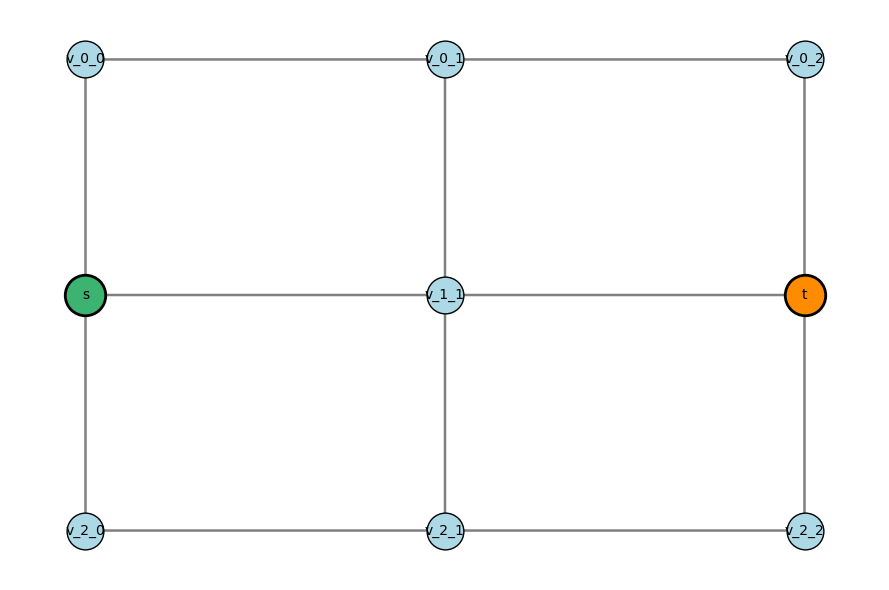

In [207]:
fig, ax = plt.subplots(figsize=(9, 6))

draw_graph(
    grid,
    source=s,
    target=t,
    positions=positions,
    ax=ax,
)

plt.tight_layout()
plt.show()

In [229]:
start = time.perf_counter()
# result_bp_grid = bp_corr2(grid, s, t, n_samples=100, seed=0, init="random")
result_bp_grid_random = bp_corr2(grid, s, t, n_samples=5000, seed=5, init="random")
runtime_bp_grid = time.perf_counter() - start


In [230]:

start = time.perf_counter()
result_spectral_grid = spectral_corr2(grid, s, t, alg="naive", n_samples=10000, seed=5)
runtime_spectral_grid = time.perf_counter() - start

start = time.perf_counter()
result_power_grid = spectral_corr2(grid, s, t, alg="power", n_samples=10000, seed=5)
runtime_power_grid = time.perf_counter() - start

In [ ]:
# result_bp_grid_zero = bp_corr2(grid, s, t, n_samples=100, seed=0, init="zero")['corr2']

In [228]:
start = time.perf_counter()
result_low_degree_grid = low_degree_corr(grid, 12, s, t)
runtime_low_degree_grid = time.perf_counter() - start

In [219]:
percolation_bound_grid = estimate_percolation_bound(grid, s, t)

In [231]:
print(f"BP: {format_estimate(result_bp_grid_random['corr2'], result_bp_grid_random['standard_error'])} (runtime: {runtime_bp_grid:.4f} s)")
# print(f"BP (zero init): {format_estimate(result_bp_grid['corr2'], result_bp_grid['standard_error'])}")
print(f"Spectral: {format_estimate(result_spectral_grid['corr2'], result_spectral_grid['standard_error'])} (runtime: {runtime_spectral_grid:.4f} s)")
print(f"Power Method: {format_estimate(result_power_grid['corr2'], result_power_grid['standard_error'])} (runtime: {runtime_power_grid:.4f} s)")
print(f"Low-degree: {format_estimate(result_low_degree_grid)} (runtime: {runtime_low_degree_grid:.4f} s)")
print(f"Percolation Upper bound: {format_estimate(percolation_bound_grid['bound'], percolation_bound_grid['standard_error'])}")

BP: estimate=0.177184, standard error=0.009932, 95% CI=[0.157717, 0.196651] (runtime: 38.7986 s)
Spectral: estimate=0.134542, standard error=0.006825, 95% CI=[0.121165, 0.147919] (runtime: 0.4411 s)
Power Method: estimate=0.134689, standard error=0.006828, 95% CI=[0.121306, 0.148072] (runtime: 2.9547 s)
Low-degree: estimate=0.174802, standard error=0.000000, 95% CI=[0.174802, 0.174802] (runtime: 0.0077 s)
Percolation Upper bound: estimate=0.198980, standard error=0.001785, 95% CI=[0.195481, 0.202479]


In [227]:
weights = compute_low_degree_weights(grid, s, t, p=0.2, degree=12)
print_low_degree_weights(grid, weights)

Edge IDs:
  0: (v_0_0, v_0_1)
  1: (v_0_1, v_0_2)
  2: (v_0_0, s)
  3: (v_0_1, v_1_1)
  4: (s, v_1_1)
  5: (v_0_2, t)
  6: (v_1_1, t)
  7: (s, v_2_0)
  8: (v_1_1, v_2_1)
  9: (v_2_0, v_2_1)
  10: (t, v_2_2)
  11: (v_2_1, v_2_2)

Low-degree weights:
  basis=(4, 6), edges=[('s', 'v_1_1'), ('v_1_1', 't')], weight=0.317522
  basis=(0, 1, 2, 5), edges=[('v_0_0', 'v_0_1'), ('v_0_1', 'v_0_2'), ('v_0_0', 's'), ('v_0_2', 't')], weight=0.095115
  basis=(0, 2, 3, 6), edges=[('v_0_0', 'v_0_1'), ('v_0_0', 's'), ('v_0_1', 'v_1_1'), ('v_1_1', 't')], weight=0.068647
  basis=(1, 3, 4, 5), edges=[('v_0_1', 'v_0_2'), ('v_0_1', 'v_1_1'), ('s', 'v_1_1'), ('v_0_2', 't')], weight=0.068647
  basis=(4, 8, 10, 11), edges=[('s', 'v_1_1'), ('v_1_1', 'v_2_1'), ('t', 'v_2_2'), ('v_2_1', 'v_2_2')], weight=0.068647
  basis=(6, 7, 8, 9), edges=[('v_1_1', 't'), ('s', 'v_2_0'), ('v_1_1', 'v_2_1'), ('v_2_0', 'v_2_1')], weight=0.068647
  basis=(7, 9, 10, 11), edges=[('s', 'v_2_0'), ('v_2_0', 'v_2_1'), ('t', 'v_2_2'), ('v_

## Misc

<Axes: title={'center': 'Heterogeneous Graph'}>

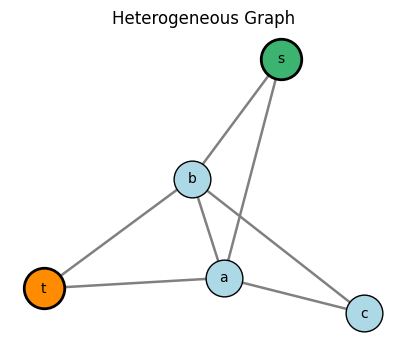

In [84]:
heterogeneous = Graph()

heterogeneous.add_edge("s", "a", 0.2)
heterogeneous.add_edge("a", "t", 0.2)

heterogeneous.add_edge("s", "b", 0.20)
heterogeneous.add_edge("b", "c", 0.2)

heterogeneous.add_edge("a", "b", 0.2)
heterogeneous.add_edge("a", "c", 0.2)
heterogeneous.add_edge("b", "t", 0.2)

draw_graph(heterogeneous, "s", "t", title="Heterogeneous Graph")

In [85]:
start = time.perf_counter()
result_bp_misc = bp_corr2(heterogeneous, "s", "t", n_samples=1000, seed=1)
runtime_bp_misc = time.perf_counter() - start

start = time.perf_counter()
result_spectral_misc = spectral_corr2(heterogeneous, "s", "t", alg="naive", n_samples=5000, seed=1)
runtime_spectral_misc = time.perf_counter() - start

start = time.perf_counter()
result_power_misc = spectral_corr2(heterogeneous, "s", "t", alg="power", n_samples=5000, seed=1)
runtime_power_misc = time.perf_counter() - start

start = time.perf_counter()
result_low_degree_misc = low_degree_corr(heterogeneous, 7, "s", "t")
runtime_low_degree_misc = time.perf_counter() - start

In [86]:
percolation_bound_misc = estimate_percolation_bound(heterogeneous, "s", "t")

In [87]:
print(f"BP: {format_estimate(result_bp_misc['corr2'], result_bp_misc['standard_error'])} (runtime: {runtime_bp_misc:.4f} s)" )
print(f"Spectral: {format_estimate(result_spectral_misc['corr2'], result_spectral_misc['standard_error'])} (runtime: {runtime_spectral_misc:.4f} s)" )
print(f"Power Method: {format_estimate(result_power_misc['corr2'], result_power_misc['standard_error'])} (runtime: {runtime_power_misc:.4f} s)" )
print(f"Low-degree: {format_estimate(result_low_degree_misc)} (runtime: {runtime_low_degree_misc:.4f} s)" )
print(f"Percolation Upper bound: {format_estimate(percolation_bound_misc['bound'], percolation_bound_misc['standard_error'])}")

BP: estimate=0.238680, 95% CI=[0.193424, 0.283936] (runtime: 4.6437 s)
Spectral: estimate=0.129025, 95% CI=[0.110439, 0.147611] (runtime: 0.1464 s)
Low-degree: estimate=0.245924, 95% CI=[0.245924, 0.245924] (runtime: 0.0005 s)
Percolation Upper bound: estimate=0.290640, 95% CI=[0.286660, 0.294620]


In [133]:

weights = compute_low_degree_weights(heterogeneous, "s", "t", p=0.2, degree=4)
print_low_degree_weights(heterogeneous, weights)

Edge IDs:
  0: (s, a)
  1: (a, t)
  2: (s, b)
  3: (b, c)
  4: (a, b)
  5: (a, c)
  6: (b, t)

Low-degree weights:
  basis=(0, 1), edges=[('s', 'a'), ('a', 't')], weight=0.281857
  basis=(2, 6), edges=[('s', 'b'), ('b', 't')], weight=0.281857
  basis=(0, 4, 6), edges=[('s', 'a'), ('a', 'b'), ('b', 't')], weight=0.076167
  basis=(1, 2, 4), edges=[('a', 't'), ('s', 'b'), ('a', 'b')], weight=0.076167
  basis=(0, 3, 5, 6), edges=[('s', 'a'), ('b', 'c'), ('a', 'c'), ('b', 't')], weight=0.033603
  basis=(1, 2, 3, 5), edges=[('a', 't'), ('s', 'b'), ('b', 'c'), ('a', 'c')], weight=0.033603


## Two clusters

In [232]:
def make_two_cluster_graph(k=4, p=0.2):
    G = Graph()

    left = ["s"] + [f"a{i}" for i in range(1, k)]
    right = ["t"] + [f"b{i}" for i in range(1, 2 * k)]

    # Dense left cluster.
    for i in range(k):
        for j in range(i + 1, k):
            G.add_edge(left[i], left[j], p)

    # Dense right cluster.
    for i in range(2 * k):
        for j in range(i + 1, 2 * k):
            G.add_edge(right[i], right[j], p)

    # Sparse cut between clusters.
    for i in range(1, k):
        G.add_edge(f"a{i}", f"b{i}", p)

    return G, "s", "t"

<Axes: title={'center': 'Two-cluster graph'}>

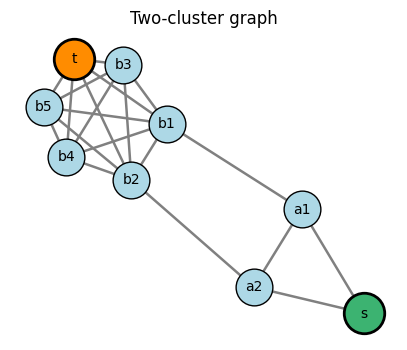

In [164]:
two_cluster_graph, s, t = make_two_cluster_graph(k=3, p=0.2)
draw_graph(two_cluster_graph, s, t, title="Two-cluster graph")

In [233]:
bp_initial_one = np.ones(2 * len(two_cluster_graph.edges))
bp_initial_zero = -np.zeros(2 * len(two_cluster_graph.edges))

In [234]:

start = time.perf_counter()
result_bp_misc_one = bp_corr2(two_cluster_graph, "s", "t", n_samples=6000, initial_point=bp_initial_one, seed=1)
runtime_bp_one = time.perf_counter() - start


# start = time.perf_counter()
# result_bp_misc_zero = bp_corr2(two_cluster_graph, "s", "t", n_samples=6000, initial_point=bp_initial_zero, seed=1)
# runtime_bp_zero = time.perf_counter() - start

start = time.perf_counter()
result_bp_misc = bp_corr2(two_cluster_graph, "s", "t", n_samples=6000, init = "random", seed=1)
runtime_bp_misc = time.perf_counter() - start


start = time.perf_counter()
result_spectral_misc = spectral_corr2(two_cluster_graph, "s", "t", alg="naive", n_samples=10000, seed=1)
runtime_spectral_misc = time.perf_counter() - start

start = time.perf_counter()
result_power_misc = spectral_corr2(two_cluster_graph, "s", "t", alg="power", n_samples=10000, seed=1)
runtime_power_misc = time.perf_counter() - start

In [252]:
start = time.perf_counter()
result_low_degree_misc = low_degree_corr(two_cluster_graph, 4, "s", "t")
runtime_low_degree_misc = time.perf_counter() - start

In [238]:
percolation_two_cluster = estimate_percolation_bound(two_cluster_graph, "s", "t")

In [253]:
print(f"BP (+1 initial point): {format_estimate(result_bp_misc_one['corr2'], result_bp_misc_one['standard_error'])} (runtime: {runtime_bp_one:.4f} s)" )
# print(f"BP (zero initial point): {format_estimate(result_bp_misc['corr2'], result_bp_misc['standard_error'])} (runtime: {runtime_bp_zero:.4f} s)" )
print(f"BP (random initial point): {format_estimate(result_bp_misc['corr2'], result_bp_misc['standard_error'])} (runtime: {runtime_bp_misc:.4f} s)" )
print(f"Spectral: {format_estimate(result_spectral_misc['corr2'], result_spectral_misc['standard_error'])} (runtime: {runtime_spectral_misc:.4f} s)" )
print(f"Power Method: {format_estimate(result_power_misc['corr2'], result_power_misc['standard_error'])} (runtime: {runtime_power_misc:.4f} s)" )
print(f"Low-degree: {format_estimate(result_low_degree_misc)} (runtime: {runtime_low_degree_misc:.4f} s)" )
print(f"Percolation Upper bound: {format_estimate(percolation_two_cluster['bound'], percolation_two_cluster['standard_error'])}")

BP (+1 initial point): estimate=0.028399, standard error=0.004270, 95% CI=[0.020031, 0.036768] (runtime: 142.4400 s)
BP (random initial point): estimate=0.033215, standard error=0.004602, 95% CI=[0.024196, 0.042235] (runtime: 144.4414 s)
Spectral: estimate=0.081339, standard error=0.005467, 95% CI=[0.070623, 0.092055] (runtime: 0.4919 s)
Power Method: estimate=0.077905, standard error=0.005361, 95% CI=[0.067398, 0.088412] (runtime: 2.9219 s)
Low-degree: estimate=0.134624, standard error=0.000000, 95% CI=[0.134624, 0.134624] (runtime: 0.0104 s)
Percolation Upper bound: estimate=0.210020, standard error=0.001822, 95% CI=[0.206450, 0.213590]


In [ ]:
weights = compute_low_degree_weights(two_cluster_graph, "s", "t", p=0.2, degree=4)
print_low_degree_weights(two_cluster_graph, weights)

Edge IDs:
  0: (s, a1)
  1: (s, a2)
  2: (a1, a2)
  3: (t, b1)
  4: (t, b2)
  5: (t, b3)
  6: (t, b4)
  7: (t, b5)
  8: (b1, b2)
  9: (b1, b3)
  10: (b1, b4)
  11: (b1, b5)
  12: (b2, b3)
  13: (b2, b4)
  14: (b2, b5)
  15: (b3, b4)
  16: (b3, b5)
  17: (b4, b5)
  18: (a1, b1)
  19: (a2, b2)

Low-degree weights:
  basis=(0, 3, 18), edges=[('s', 'a1'), ('t', 'b1'), ('a1', 'b1')], weight=0.141184
  basis=(1, 4, 19), edges=[('s', 'a2'), ('t', 'b2'), ('a2', 'b2')], weight=0.141184
  basis=(0, 2, 4, 19), edges=[('s', 'a1'), ('a1', 'a2'), ('t', 'b2'), ('a2', 'b2')], weight=0.051139
  basis=(0, 4, 8, 18), edges=[('s', 'a1'), ('t', 'b2'), ('b1', 'b2'), ('a1', 'b1')], weight=0.046373
  basis=(0, 5, 9, 18), edges=[('s', 'a1'), ('t', 'b3'), ('b1', 'b3'), ('a1', 'b1')], weight=0.052367
  basis=(0, 6, 10, 18), edges=[('s', 'a1'), ('t', 'b4'), ('b1', 'b4'), ('a1', 'b1')], weight=0.052367
  basis=(0, 7, 11, 18), edges=[('s', 'a1'), ('t', 'b5'), ('b1', 'b5'), ('a1', 'b1')], weight=0.052367
  basis=(1,